In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = "../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (235795, 56)


In [3]:
TARGET_COLUMN = "label"
URL_COLUMN = "URL"

print("Target:", TARGET_COLUMN)
print("URL:", URL_COLUMN)

Target: label
URL: URL


In [5]:
target_counts = df[TARGET_COLUMN].value_counts()

print(target_counts)

target_percent = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True)
    * 100
)

print(target_percent)

label
1    134850
0    100945
Name: count, dtype: int64
label
1    57.189508
0    42.810492
Name: proportion, dtype: float64


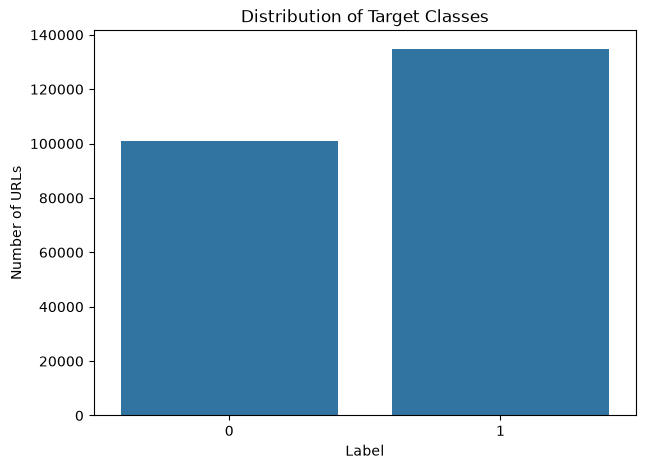

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=TARGET_COLUMN
)

plt.title("Distribution of Target Classes")
plt.xlabel("Label")
plt.ylabel("Number of URLs")

plt.show()

In [34]:
phishing = df[df[TARGET_COLUMN] == 0]
legitimate = df[df[TARGET_COLUMN] == 1]

print("Phishing samples:", len(phishing))
print("Legitimate samples:", len(legitimate))

Phishing samples: 100945
Legitimate samples: 134850


In [35]:
print("Legitimate URL length:")
print(legitimate["URLLength"].describe())

print("\nPhishing URL length:")
print(phishing["URLLength"].describe())

Legitimate URL length:
count    134850.000000
mean         26.228610
std           4.815612
min          15.000000
25%          23.000000
50%          26.000000
75%          29.000000
max          57.000000
Name: URLLength, dtype: float64

Phishing URL length:
count    100945.000000
mean         45.720293
std          61.145523
min          13.000000
25%          26.000000
50%          34.000000
75%          48.000000
max        6097.000000
Name: URLLength, dtype: float64


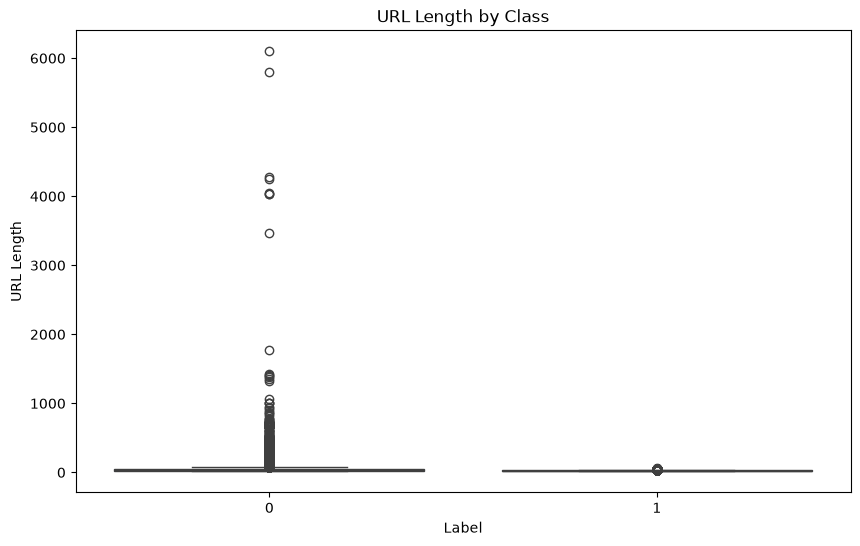

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y="URLLength"
)

plt.title("URL Length by Class")
plt.xlabel("Label")
plt.ylabel("URL Length")

plt.show()

          count       mean        std  min   25%   50%   75%    max
label                                                              
0      100945.0  24.465144  12.204054  4.0  16.0  22.0  29.0  110.0
1      134850.0  19.228610   4.815612  8.0  16.0  19.0  22.0   50.0


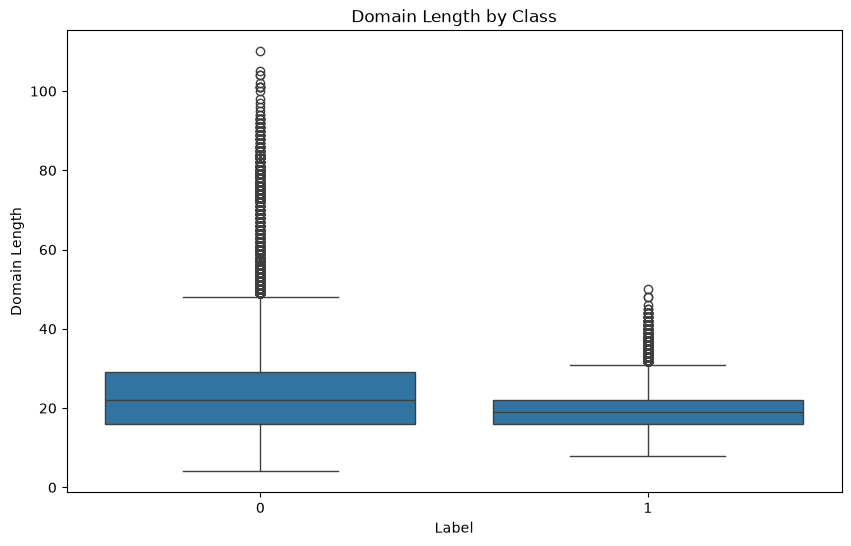

In [39]:
print(
    df.groupby(TARGET_COLUMN)["DomainLength"]
    .describe()
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y="DomainLength"
)

plt.title("Domain Length by Class")
plt.xlabel("Label")
plt.ylabel("Domain Length")

plt.show()

          count      mean       std  min  25%  50%  75%   max
label                                                        
0      100945.0  1.168894  0.790880  0.0  1.0  1.0  1.0  10.0
1      134850.0  1.161661  0.404076  1.0  1.0  1.0  1.0   4.0


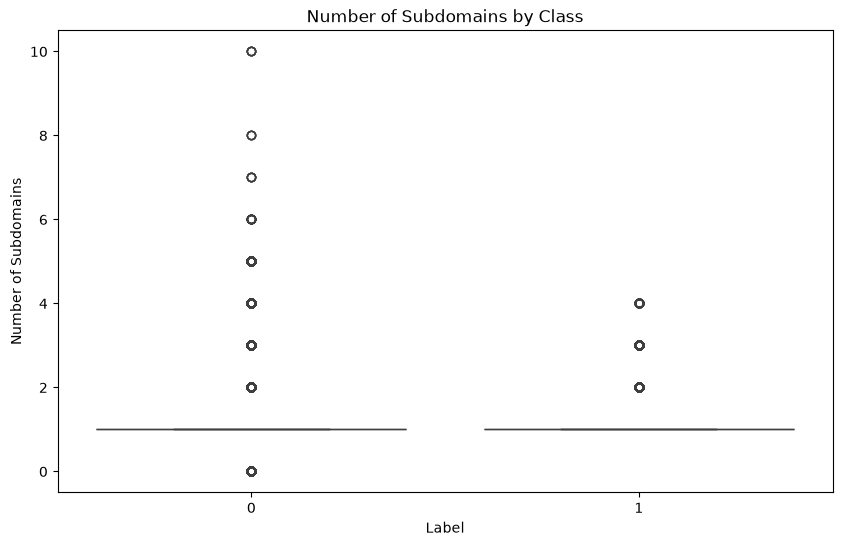

In [40]:
print(
    df.groupby(TARGET_COLUMN)["NoOfSubDomain"]
    .describe()
)
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y="NoOfSubDomain"
)

plt.title("Number of Subdomains by Class")
plt.xlabel("Label")
plt.ylabel("Number of Subdomains")

plt.show()

label             0          1
IsHTTPS                       
0        100.000000   0.000000
1         26.926016  73.073984


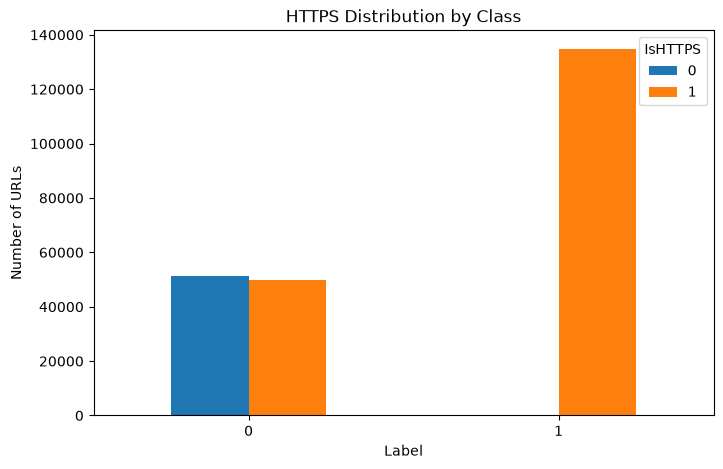

In [41]:
print(
    pd.crosstab(
        df["IsHTTPS"],
        df[TARGET_COLUMN],
        normalize="index"
    ) * 100
)
https_distribution = pd.crosstab(
    df[TARGET_COLUMN],
    df["IsHTTPS"]
)

https_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("HTTPS Distribution by Class")
plt.xlabel("Label")
plt.ylabel("Number of URLs")

plt.xticks(rotation=0)
plt.show()

In [42]:
print(
    pd.crosstab(
        df["IsDomainIP"],
        df[TARGET_COLUMN],
        normalize="index"
    ) * 100
)

label                0          1
IsDomainIP                       
0            42.655332  57.344668
1           100.000000   0.000000


       HasObfuscation  NoOfObfuscatedChar  ObfuscationRatio
label                                                      
0            0.004805            0.058071          0.000323
1            0.000000            0.000000          0.000000


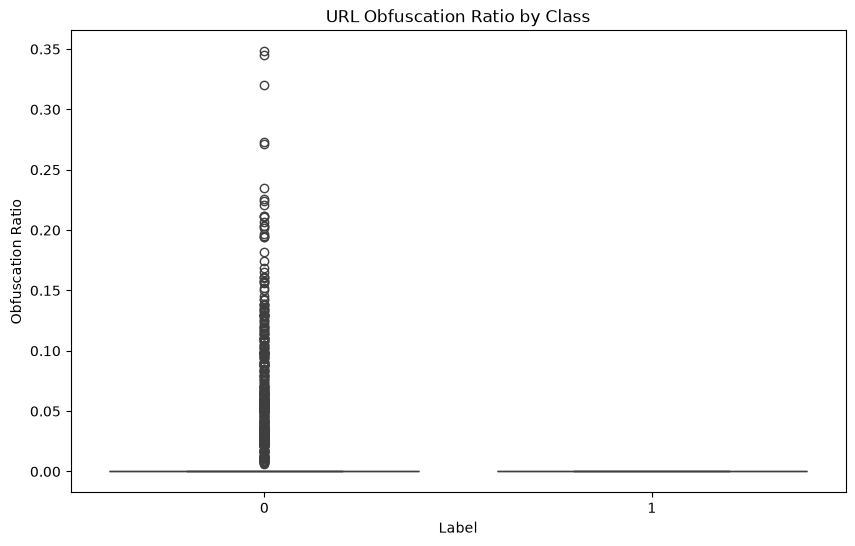

In [43]:
print(
    df.groupby(TARGET_COLUMN)[
        [
            "HasObfuscation",
            "NoOfObfuscatedChar",
            "ObfuscationRatio"
        ]
    ].mean()
)
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y="ObfuscationRatio"
)

plt.title("URL Obfuscation Ratio by Class")
plt.xlabel("Label")
plt.ylabel("Obfuscation Ratio")

plt.show()

In [44]:
special_features = [
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL"
]

print(
    df.groupby(TARGET_COLUMN)[special_features].mean()
)

       NoOfEqualsInURL  NoOfQMarkInURL  NoOfAmpersandInURL  \
label                                                        
0             0.145386        0.068681            0.058527   
1             0.000000        0.000000            0.000000   

       NoOfOtherSpecialCharsInURL  SpacialCharRatioInURL  
label                                                     
0                        3.803467               0.083285  
1                        1.244835               0.048356  


       NoOfDegitsInURL  DegitRatioInURL
label                                  
0             4.326217         0.064018
1             0.050597         0.002115


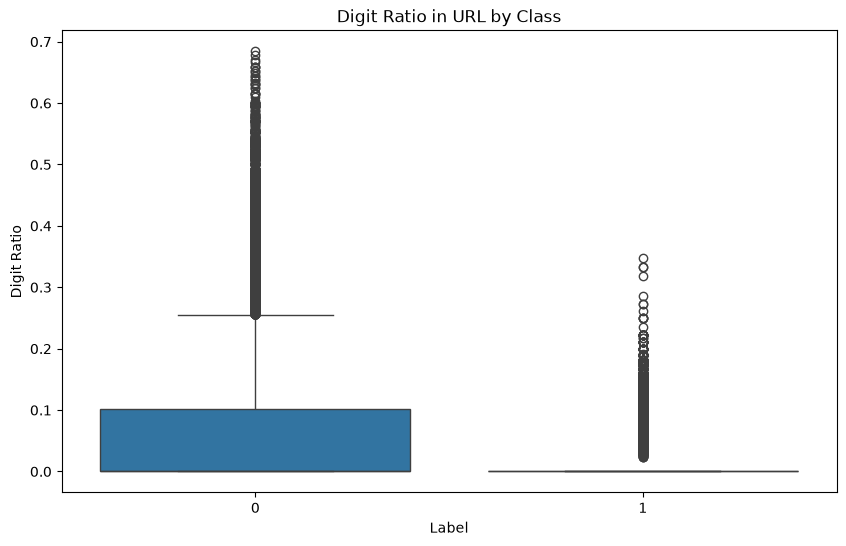

In [45]:
digit_features = [
    "NoOfDegitsInURL",
    "DegitRatioInURL"
]

print(
    df.groupby(TARGET_COLUMN)[digit_features].mean()
)
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y="DegitRatioInURL"
)

plt.title("Digit Ratio in URL by Class")
plt.xlabel("Label")
plt.ylabel("Digit Ratio")

plt.show()

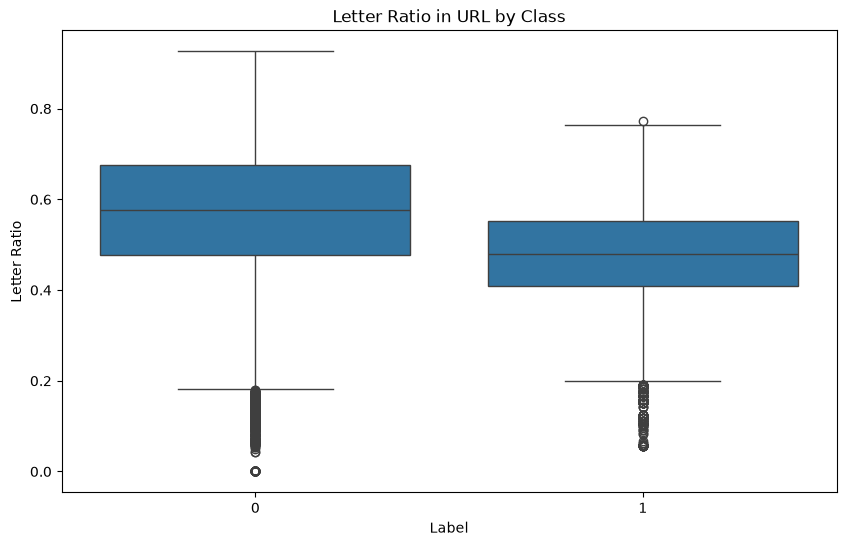

In [46]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y="LetterRatioInURL"
)

plt.title("Letter Ratio in URL by Class")
plt.xlabel("Label")
plt.ylabel("Letter Ratio")

plt.show()

          count        mean        std         min         25%         50%  \
label                                                                        
0      100945.0   49.616973  22.572082    0.155574   32.120613   51.419332   
1      134850.0  100.000000   0.000000  100.000000  100.000000  100.000000   

              75%    max  
label                     
0       67.251462  100.0  
1      100.000000  100.0  


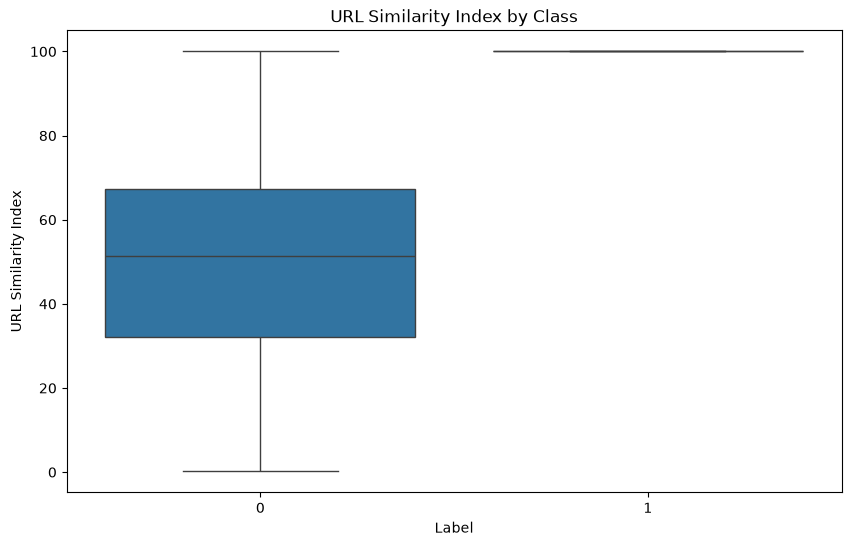

In [47]:
print(
    df.groupby(TARGET_COLUMN)["URLSimilarityIndex"]
    .describe()
)
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x=TARGET_COLUMN,
    y="URLSimilarityIndex"
)

plt.title("URL Similarity Index by Class")
plt.xlabel("Label")
plt.ylabel("URL Similarity Index")

plt.show()

In [48]:
web_features = [
    "HasSocialNet",
    "HasCopyrightInfo",
    "HasDescription",
    "HasSubmitButton",
    "IsResponsive",
    "HasHiddenFields",
    "HasFavicon",
    "HasTitle",
    "Robots",
    "Pay",
    "Bank"
]

print(
    df.groupby(TARGET_COLUMN)[web_features].mean().T
)

label                    0         1
HasSocialNet      0.005062  0.794557
HasCopyrightInfo  0.057338  0.808239
HasDescription    0.044163  0.736633
HasSubmitButton   0.084898  0.660882
IsResponsive      0.317460  0.854364
HasHiddenFields   0.093279  0.590782
HasFavicon        0.087572  0.567023
HasTitle          0.677587  0.998754
Robots            0.065897  0.416737
Pay               0.060191  0.369366
Bank              0.054346  0.181542


In [49]:
reference_features = [
    "NoOfSelfRef",
    "NoOfEmptyRef",
    "NoOfExternalRef"
]

print(
    df.groupby(TARGET_COLUMN)[reference_features].mean()
)

       NoOfSelfRef  NoOfEmptyRef  NoOfExternalRef
label                                            
0         0.496032      0.150379         1.128119
1       113.410241      4.044887        85.294601


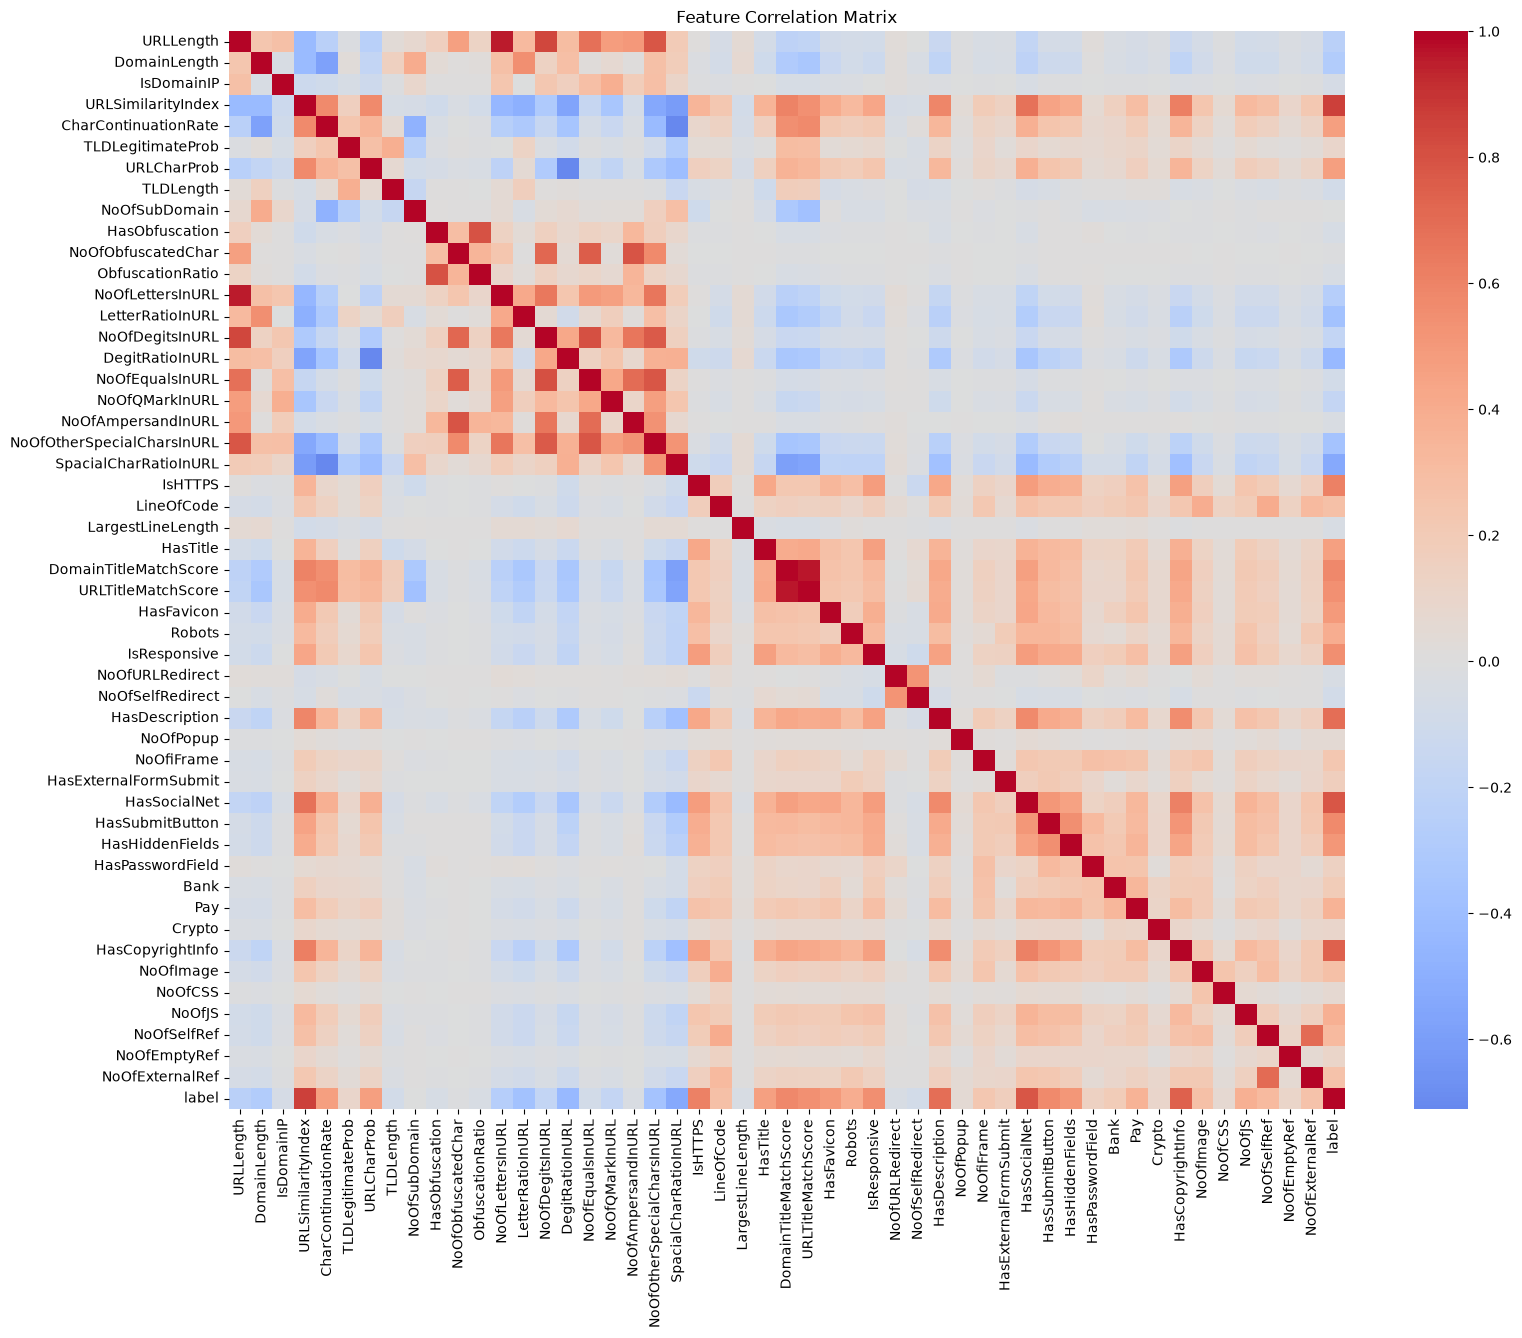

In [50]:
numeric_features = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_features.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [51]:
label_correlations = (
    numeric_features
    .corr()[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .abs()
    .sort_values(ascending=False)
)

print(label_correlations.head(20))

URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL    0.533537
HasHiddenFields          0.507731
HasFavicon               0.493711
URLCharProb              0.469749
CharContinuationRate     0.467735
HasTitle                 0.459725
DegitRatioInURL          0.432032
Robots                   0.392620
NoOfJS                   0.373500
LetterRatioInURL         0.367794
Pay                      0.359747
Name: label, dtype: float64


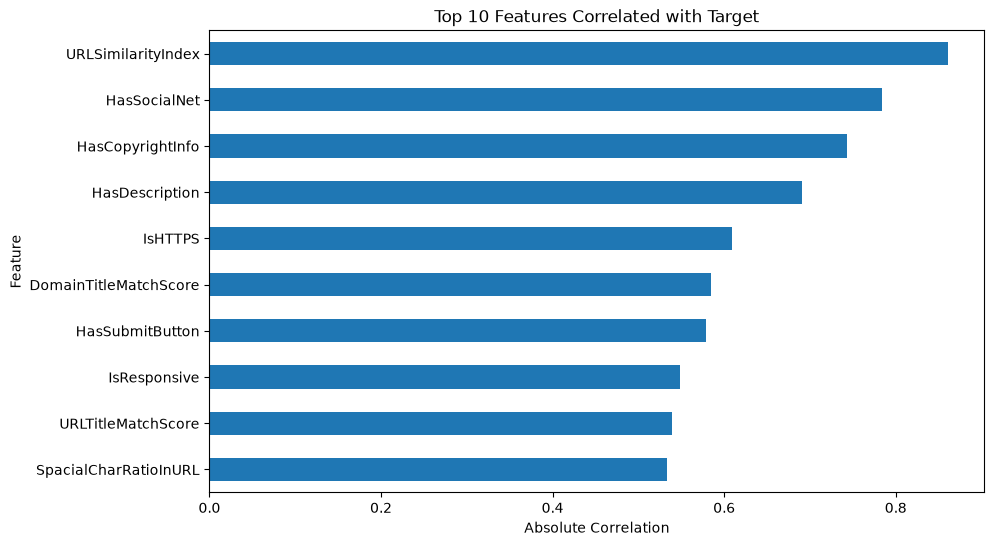

In [52]:
top_features = label_correlations.head(10)

plt.figure(figsize=(10, 6))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Features Correlated with Target")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()

In [53]:
high_corr_features = [
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "URLLength",
    "NoOfLettersInURL"
]

print(
    df[high_corr_features].describe()
)
print(
    df[high_corr_features]
    .corr()
)

       DomainTitleMatchScore  URLTitleMatchScore      URLLength  \
count          235795.000000       235795.000000  235795.000000   
mean               50.131427           52.122098      34.573095   
std                49.676981           49.600564      41.314153   
min                 0.000000            0.000000      13.000000   
25%                 0.000000            0.000000      23.000000   
50%                75.000000          100.000000      27.000000   
75%               100.000000          100.000000      34.000000   
max               100.000000          100.000000    6097.000000   

       NoOfLettersInURL  
count     235795.000000  
mean          19.428919  
std           29.090330  
min            0.000000  
25%           10.000000  
50%           14.000000  
75%           20.000000  
max         5191.000000  
                       DomainTitleMatchScore  URLTitleMatchScore  URLLength  \
DomainTitleMatchScore               1.000000            0.961008  -0.215877   
URLT

In [54]:
binary_features = []

for column in df.select_dtypes(include=np.number).columns:
    unique_values = set(df[column].dropna().unique())

    if unique_values.issubset({0, 1}):
        binary_features.append(column)

print("Binary features:")
for feature in binary_features:
    print("-", feature)

Binary features:
- IsDomainIP
- HasObfuscation
- IsHTTPS
- HasTitle
- HasFavicon
- Robots
- IsResponsive
- NoOfURLRedirect
- NoOfSelfRedirect
- HasDescription
- HasExternalFormSubmit
- HasSocialNet
- HasSubmitButton
- HasHiddenFields
- HasPasswordField
- Bank
- Pay
- Crypto
- HasCopyrightInfo
- label


In [55]:
binary_comparison = (
    df.groupby(TARGET_COLUMN)[binary_features]
    .mean()
    .T
)

print(binary_comparison)

label                         0         1
IsDomainIP             0.006320  0.000000
HasObfuscation         0.004805  0.000000
IsHTTPS                0.492238  1.000000
HasTitle               0.677587  0.998754
HasFavicon             0.087572  0.567023
Robots                 0.065897  0.416737
IsResponsive           0.317460  0.854364
NoOfURLRedirect        0.151696  0.119770
NoOfSelfRedirect       0.057447  0.027126
HasDescription         0.044163  0.736633
HasExternalFormSubmit  0.004270  0.073719
HasSocialNet           0.005062  0.794557
HasSubmitButton        0.084898  0.660882
HasHiddenFields        0.093279  0.590782
HasPasswordField       0.053871  0.138487
Bank                   0.054346  0.181542
Pay                    0.060191  0.369366
Crypto                 0.006043  0.036522
HasCopyrightInfo       0.057338  0.808239
label                  0.000000  1.000000


In [56]:
feature_screen = pd.DataFrame({
    "feature": label_correlations.index,
    "abs_correlation_with_label": label_correlations.values
})

feature_screen.head(20)

,feature,abs_correlation_with_label
0,URLSimilarityIndex,0.860358
1,HasSocialNet,0.784255
2,HasCopyrightInfo,0.743358
3,HasDescription,0.690232
4,IsHTTPS,0.609132
5,DomainTitleMatchScore,0.584905
6,HasSubmitButton,0.578561
7,IsResponsive,0.548608
8,URLTitleMatchScore,0.539419
9,SpacialCharRatioInURL,0.533537


In [57]:
feature_categories = {
    "URL_based": [
        "URLLength",
        "DomainLength",
        "IsDomainIP",
        "NoOfSubDomain",
        "NoOfObfuscatedChar",
        "ObfuscationRatio",
        "NoOfLettersInURL",
        "LetterRatioInURL",
        "NoOfDegitsInURL",
        "DegitRatioInURL",
        "NoOfEqualsInURL",
        "NoOfQMarkInURL",
        "NoOfAmpersandInURL",
        "NoOfOtherSpecialCharsInURL",
        "SpacialCharRatioInURL",
        "IsHTTPS"
    ],

    "Identifier": [
        "FILENAME"
    ]
}

print(feature_categories)

{'URL_based': ['URLLength', 'DomainLength', 'IsDomainIP', 'NoOfSubDomain', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS'], 'Identifier': ['FILENAME']}


In [58]:
feature_decisions = {
    "FILENAME": "DROP - identifier/dataset artifact",
    "URL": "KEEP FOR URL PROCESSING / REPUTATION",
    "label": "TARGET - not an input feature"
}

for feature, decision in feature_decisions.items():
    print(f"{feature}: {decision}")

FILENAME: DROP - identifier/dataset artifact
URL: KEEP FOR URL PROCESSING / REPUTATION
label: TARGET - not an input feature


In [59]:
print("=" * 70)
print("PHASE 3 — EDA SUMMARY")
print("=" * 70)

print(f"Total samples       : {len(df):,}")
print(f"Total features      : {df.shape[1]}")
print(f"Target column       : {TARGET_COLUMN}")
print(f"Phishing samples    : {(df[TARGET_COLUMN] == 0).sum():,}")
print(f"Legitimate samples  : {(df[TARGET_COLUMN] == 1).sum():,}")

print("\nTop features correlated with target:")
print(label_correlations.head(10))

print("\nBinary features:")
print(binary_features)

PHASE 3 — EDA SUMMARY
Total samples       : 235,795
Total features      : 56
Target column       : label
Phishing samples    : 100,945
Legitimate samples  : 134,850

Top features correlated with target:
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL    0.533537
Name: label, dtype: float64

Binary features:
['IsDomainIP', 'HasObfuscation', 'IsHTTPS', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'label']
